In [2]:
print('Welcome to class')

Welcome to class


In [ ]:
## MNIST dataset

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [5]:
device

'cuda'

In [6]:
transform = transforms.Compose([transforms.ToTensor()]) # [0,255] --> [0,1]
train_data = datasets.MNIST(root = './data', train=True, download=True, transform = transform)
test_data = datasets.MNIST(root = './data', train=False, download=True, transform = transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True) # avoid order bias
test_loader = DataLoader(test_data, batch_size=128, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 511kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.39MB/s]


In [7]:
def add_noise(x, noise_level = 0.3):
  noise = torch.randn_like(x) * noise_level
  x_noisy = x + noise
  return torch.clamp(x_noisy, 0, 1) # values stay in [0,1 ]

In [ ]:
## Denoising Convolution AutoEncoder

In [11]:
# dir(nn.Mo)

In [16]:
class DenoisingConvAutoEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder =  nn.Sequential(
        # 1 -- channel --> 32 filters --> kernel size =3
        nn.Conv2d(1,32,3,stride=2,padding=1),
        nn.ReLU(),
        nn.Conv2d(32, 64, 3, stride = 2, padding=1),
        nn.ReLU()
    )
    self.decoder = nn.Sequential(
        #output_padding=1 ensures output matches input size
        nn.ConvTranspose2d(64,32,3,stride=2, padding=1, output_padding=1),
        nn.ReLU(),
        nn.ConvTranspose2d(32,1,3,stride=2, padding=1, output_padding=1),
        nn.Sigmoid() # outputs are in b/w [0 and 1]
    )


  def forward(self, x):
    z = self.encoder(x)
    return self.decoder(z)

In [17]:

model = DenoisingConvAutoEncoder().to(device)
optimizer = optim.Adam(model.parameters(), lr = 1e-3)
criterion = nn.MSELoss()

epochs = 5

for epoch in range(epochs):
  model.train()
  total_loss=0

  for x,_ in train_loader:
    x = x.to(device) # takes data to GPU
    x_noisy = add_noise(x)

    optimizer.zero_grad()
    x_hat = model(x_noisy)
    loss = criterion(x_hat, x)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

  print(f'Epoch {epoch} : Loss: {total_loss/len(train_loader)}: train_loader : {len(train_loader)}')


Epoch 0 : Loss: 0.019731259568215115: train_loader : 469
Epoch 1 : Loss: 0.0058374378218579645: train_loader : 469
Epoch 2 : Loss: 0.005577390255934712: train_loader : 469
Epoch 3 : Loss: 0.005430732941084198: train_loader : 469
Epoch 4 : Loss: 0.005325386112035591: train_loader : 469


In [18]:
model.eval()

with torch.no_grad():
  x, _ = next(iter(test_loader))
  x  = x.to(device)
  x_noisy = add_noise(x)
  x_hat = model(x_noisy)


In [19]:
x_hat

tensor([[[[4.5734e-04, 1.7409e-04, 2.8136e-04,  ..., 2.2020e-04,
           1.8401e-03, 7.7017e-03],
          [8.9632e-05, 1.3221e-05, 6.0255e-05,  ..., 4.9824e-05,
           8.7378e-04, 2.6924e-03],
          [8.6355e-05, 6.1807e-06, 1.2470e-04,  ..., 5.1491e-05,
           1.3182e-03, 3.1106e-03],
          ...,
          [9.3876e-05, 1.2707e-05, 9.1621e-05,  ..., 4.5006e-04,
           2.7459e-03, 5.2653e-03],
          [1.3308e-03, 7.0269e-05, 7.8881e-04,  ..., 3.7195e-04,
           6.6687e-03, 6.4922e-03],
          [2.1938e-03, 1.5872e-03, 2.0471e-03,  ..., 4.7304e-03,
           7.5680e-03, 1.2945e-02]]],


        [[[5.4474e-04, 3.4528e-04, 2.9099e-03,  ..., 5.6480e-04,
           3.0904e-03, 9.6964e-03],
          [2.3358e-04, 1.4824e-04, 5.3243e-03,  ..., 2.5134e-04,
           1.8392e-03, 4.2628e-03],
          [1.9435e-04, 4.4079e-05, 9.1534e-04,  ..., 7.2108e-05,
           1.0314e-03, 3.6654e-03],
          ...,
          [1.0022e-04, 1.5191e-05, 1.0665e-04,  ..., 1.28

In [21]:
len(test_loader)

79

In [20]:
len(x_hat)

128

In [22]:

len(x)

128

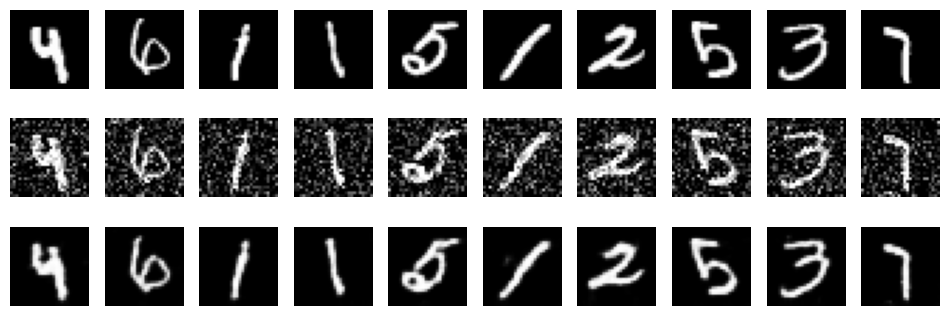

In [25]:
plt.figure(figsize=(12,4))
n = 10
for i in range(n):

  ##Original

  plt.subplot(3,n,i+1)
  plt.imshow(x[i].cpu().squeeze(), cmap='gray')
  plt.axis('off')
  ## Noisy
  plt.subplot(3,n,i+n+1)
  plt.imshow(x_noisy[i].cpu().squeeze(), cmap='gray')
  plt.axis('off')


  ## Reconstructed
  plt.subplot(3,n,i+2*n+1)
  plt.imshow(x_hat[i].cpu().squeeze(), cmap='gray')
  plt.axis('off')

